# 2.3: Влияние размера истории L-BFGS

In [ ]:
import urllib.request
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse
from sklearn.datasets import load_svmlight_file
from oracles import LogCoshL2Oracle, ExponentialLossL2Oracle
from optimization import lbfgs

rng = np.random.default_rng(78)

In [ ]:
LIBSVM_BASE = "https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets"
data_dir = Path("data/libsvm")
data_dir.mkdir(parents=True, exist_ok=True)

def ensure_dataset(name, rel_url):
    path = data_dir / name
    if not path.exists():
        req = urllib.request.Request(f"{LIBSVM_BASE}/{rel_url}", headers={"User-Agent": "MetOpt-lab/2.0"})
        with urllib.request.urlopen(req, timeout=300) as r, open(path, "wb") as f:
            f.write(r.read())
    return path

def labels_pm_one(y):
    y = np.asarray(y, dtype=float).ravel()
    u = np.unique(y)
    if len(u) == 2 and 0.0 in u and 1.0 in u:
        return 2.0 * y - 1.0
    return y

reg_path = ensure_dataset("abalone_scale", "regression/abalone_scale")
clf_path = ensure_dataset("a9a", "binary/a9a")
X_reg, y_reg = load_svmlight_file(reg_path)
X_clf, y_clf = load_svmlight_file(clf_path)
X_reg = X_reg.tocsr().astype(np.float64)
X_clf = X_clf.tocsr().astype(np.float64)
y_reg = np.asarray(y_reg, dtype=np.float64).ravel()
y_clf = labels_pm_one(y_clf)

def sparse_oracle_ops(X):
    def matvec_Ax(x):
        return X.dot(np.asarray(x, dtype=np.float64).ravel())
    def matvec_ATx(v):
        return X.T.dot(np.asarray(v, dtype=np.float64).ravel())
    def matmat_ATsA(s):
        s = np.asarray(s, dtype=np.float64).ravel()
        return X.T.dot(sparse.diags(s).dot(X)).toarray()
    return matvec_Ax, matvec_ATx, matmat_ATsA

In [ ]:
m_reg, n_reg = X_reg.shape
m_clf, n_clf = X_clf.shape
regcoef_reg = 1.0 / m_reg
regcoef_clf = 1.0 / m_clf
ops_reg = sparse_oracle_ops(X_reg)
ops_clf = sparse_oracle_ops(X_clf)
oracle_reg = LogCoshL2Oracle(*ops_reg, y_reg, regcoef_reg)
oracle_clf = ExponentialLossL2Oracle(*ops_clf, y_clf, regcoef_clf)

memory_sizes = [0, 1, 5, 10, 50, 100]
x0_reg = np.zeros(n_reg)
x0_clf = np.zeros(n_clf)

def run_suite(oracle, x0, title):
    traces = {}
    for l in memory_sizes:
        _, msg, hist = lbfgs(
            oracle, x0,
            tolerance=1e-8,
            max_iter=300,
            memory_size=l,
            line_search_options={'method': 'Wolfe', 'c1': 1e-4, 'c2': 0.9, 'alpha_0': 1.0},
            trace=True,
        )
        traces[l] = (msg, hist)
    return traces

tr_reg = run_suite(oracle_reg, x0_reg, 'Regression')
tr_clf = run_suite(oracle_clf, x0_clf, 'Classification')

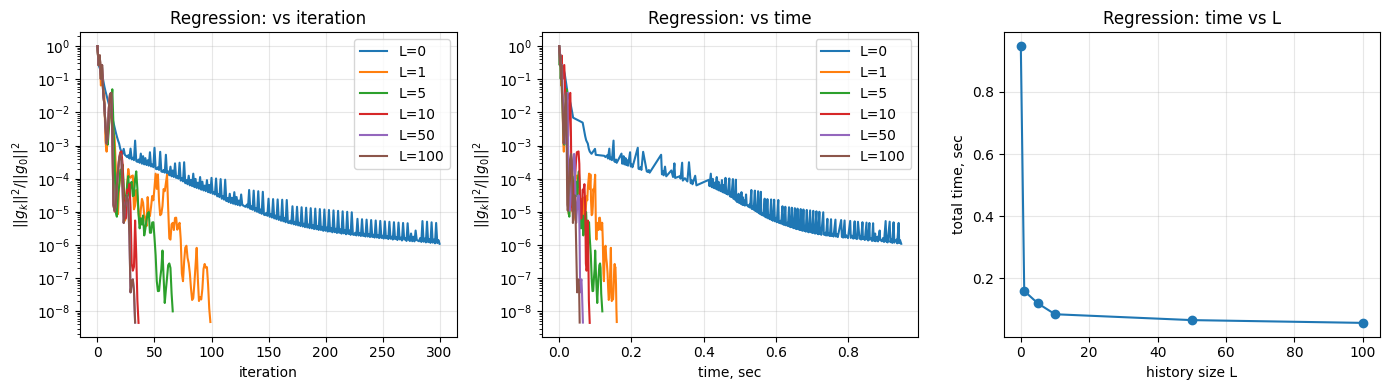

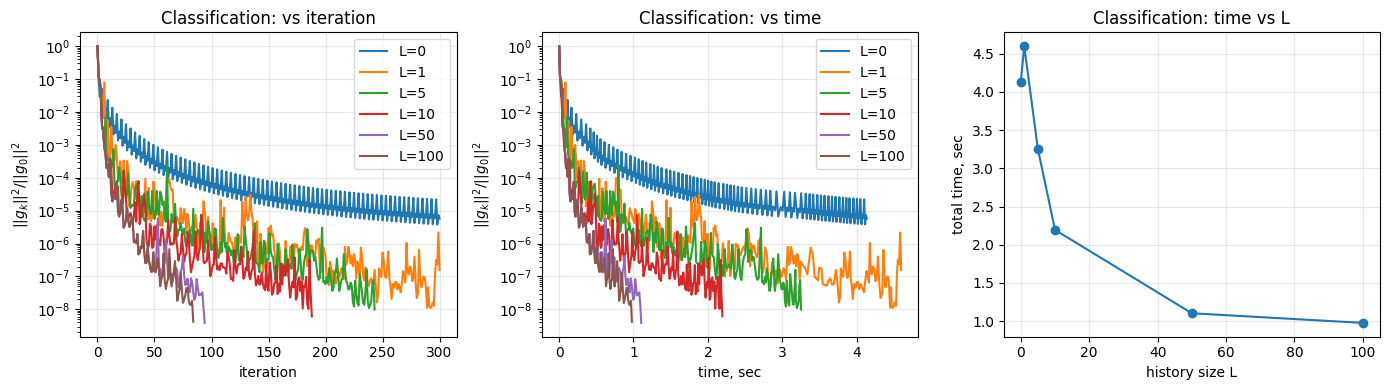

In [ ]:
def plot_curves(traces, name, save_name):
    plt.figure(figsize=(14, 4))

    plt.subplot(1, 3, 1)
    for l, (_, hist) in traces.items():
        g = np.array(hist['grad_norm'])
        rel = (g ** 2) / max(g[0] ** 2, 1e-32)
        plt.plot(rel, label=f'L={l}')
    plt.yscale('log')
    plt.xlabel('iteration')
    plt.ylabel(r'$||g_k||^2 / ||g_0||^2$')
    plt.title(f'{name}: vs iteration')
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.subplot(1, 3, 2)
    total_times = []
    for l, (_, hist) in traces.items():
        g = np.array(hist['grad_norm'])
        rel = (g ** 2) / max(g[0] ** 2, 1e-32)
        t = np.array(hist['time'])
        plt.plot(t, rel, label=f'L={l}')
        total_times.append(t[-1])
    plt.yscale('log')
    plt.xlabel('time, sec')
    plt.ylabel(r'$||g_k||^2 / ||g_0||^2$')
    plt.title(f'{name}: vs time')
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(memory_sizes, total_times, marker='o')
    plt.xlabel('history size L')
    plt.ylabel('total time, sec')
    plt.title(f'{name}: time vs L')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    Path('fig').mkdir(parents=True, exist_ok=True)
    plt.savefig(f'fig/{save_name}', dpi=200, bbox_inches='tight')

plot_curves(tr_reg, 'Regression', 'exp2_3_lbfgs_memory_regression.png')
plot_curves(tr_clf, 'Classification', 'exp2_3_lbfgs_memory_classification.png')

In [ ]:
table = []
for L in memory_sizes:
    mem_reg = 2 * n_reg * L
    mem_clf = 2 * n_clf * L
    flops_reg = 8 * n_reg * max(L, 1)
    flops_clf = 8 * n_clf * max(L, 1)
    table.append((L, mem_reg, mem_clf, flops_reg, flops_clf))

table

[(0, 0, 0, 64, 984),
 (1, 16, 246, 64, 984),
 (5, 80, 1230, 320, 4920),
 (10, 160, 2460, 640, 9840),
 (50, 800, 12300, 3200, 49200),
 (100, 1600, 24600, 6400, 98400)]